# Actividad 2: Clubes de convergencia en series temporales
**Asignatura:** Gestión de Proyectos de Inteligencia de Negocio | **Fecha:** Mayo 2026

---
Este notebook analiza el dataset `dataset_provincias.csv` con datos mensuales de ventas de cigarrillos por provincia española (enero 2005 – diciembre 2021), procedentes del Ministerio de Industria, Turismo y Comercio.

El objetivo es proporcionar a la dirección de una multinacional tabaquera información sobre si las provincias se comportan de forma homogénea o si existen grupos diferenciados que justifiquen estrategias comerciales distintas.

## Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset
df = pd.read_csv('dataset_provincias.csv', index_col=0)

print(f'Dataset: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.head(3)

Dataset: 9,792 filas, 10 columnas


,Provincias,Year,Mes,dia,fecha,Población,Unidades,Euros,precio,UdesxCapita
1,Álava,2005,1,15,2005-01-15,260982,2009297.50,4483980.2,2.231616,7.698989
2,Albacete,2005,1,15,2005-01-15,314481,2427114.75,5350696.5,2.204550,7.717842
3,Alicante/Alacant,2005,1,15,2005-01-15,1405806,19032873.70,44436908.2,2.334745,13.538763


## Limpieza básica

Antes de empezar, detectamos y corregimos un problema habitual en datasets con nombres de texto: espacios extra al final de los valores. En este caso, la provincia "Granada" aparece duplicada (con y sin espacio final). Lo solucionamos con `str.strip()`.

También construimos una columna de fecha mensual propia a partir de `Year` y `Mes`, usando el día 1 de cada mes. La columna `dia` original siempre vale 15 (valor orientativo) y no la usaremos directamente.

In [2]:
# Limpieza de espacios en nombres de provincias
print(f'Provincias antes de limpiar: {df["Provincias"].nunique()}')
df['Provincias'] = df['Provincias'].str.strip()
print(f'Provincias después de limpiar: {df["Provincias"].nunique()}')

# Construimos la fecha mensual como primer día de cada mes
# Esto es necesario para que statsmodels reconozca la frecuencia mensual (freq='MS')
df['fecha_ts'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Mes'].astype(str).str.zfill(2) + '-01'
)

print(f'\nRango temporal: {df["fecha_ts"].min()} a {df["fecha_ts"].max()}')
print(f'Meses por provincia: {df.groupby("Provincias")["fecha_ts"].nunique().iloc[0]}')

Provincias antes de limpiar: 49
Provincias después de limpiar: 48

Rango temporal: 2005-01-01 00:00:00 a 2021-12-01 00:00:00
Meses por provincia: 204


---
## Pregunta 1: Tipos de variables y series temporales

**¿De qué tipo de variables se compone el dataset? Realiza una representación gráfica que permita conocer el comportamiento de la serie temporal de ventas per cápita en cada una de las provincias. Describe brevemente los hallazgos más relevantes.**

Empezamos identificando los tipos de variables del dataset.

In [3]:
print('=== TIPOS DE VARIABLES ===')
print(df.dtypes)
print(f'\nVariables categóricas: Provincias ({df["Provincias"].nunique()} valores únicos)')
print(f'Variables temporales: Year (2005-2021), Mes (1-12), dia (siempre 15), fecha, fecha_ts')
print(f'Variables numéricas continuas: Población, Unidades, Euros, precio, UdesxCapita')

=== TIPOS DE VARIABLES ===
Provincias             object
Year                    int64
Mes                     int64
dia                     int64
fecha                  object
Población               int64
Unidades              float64
Euros                 float64
precio                float64
UdesxCapita           float64
fecha_ts       datetime64[ns]
dtype: object

Variables categóricas: Provincias (48 valores únicos)
Variables temporales: Year (2005-2021), Mes (1-12), dia (siempre 15), fecha, fecha_ts
Variables numéricas continuas: Población, Unidades, Euros, precio, UdesxCapita


Antes de continuar, verificamos la errata del enunciado: éste indica que `UdesxCapita` se calcula como Euros / Población, pero en realidad es **Unidades / Población** (ventas en cajetillas per cápita, no en euros).

In [4]:
# Verificación de la variable UdesxCapita
check_unidades = np.allclose(df['UdesxCapita'], df['Unidades'] / df['Población'])
check_euros = np.allclose(df['UdesxCapita'], df['Euros'] / df['Población'])

print(f'UdesxCapita = Unidades / Población: {check_unidades}')
print(f'UdesxCapita = Euros / Población:    {check_euros}')
print('\n--> Confirmado: UdesxCapita es Unidades / Población (cajetillas per cápita)')

UdesxCapita = Unidades / Población: True
UdesxCapita = Euros / Población:    False

--> Confirmado: UdesxCapita es Unidades / Población (cajetillas per cápita)


Representamos la serie temporal de `UdesxCapita` para las 48 provincias en un mismo gráfico de líneas.

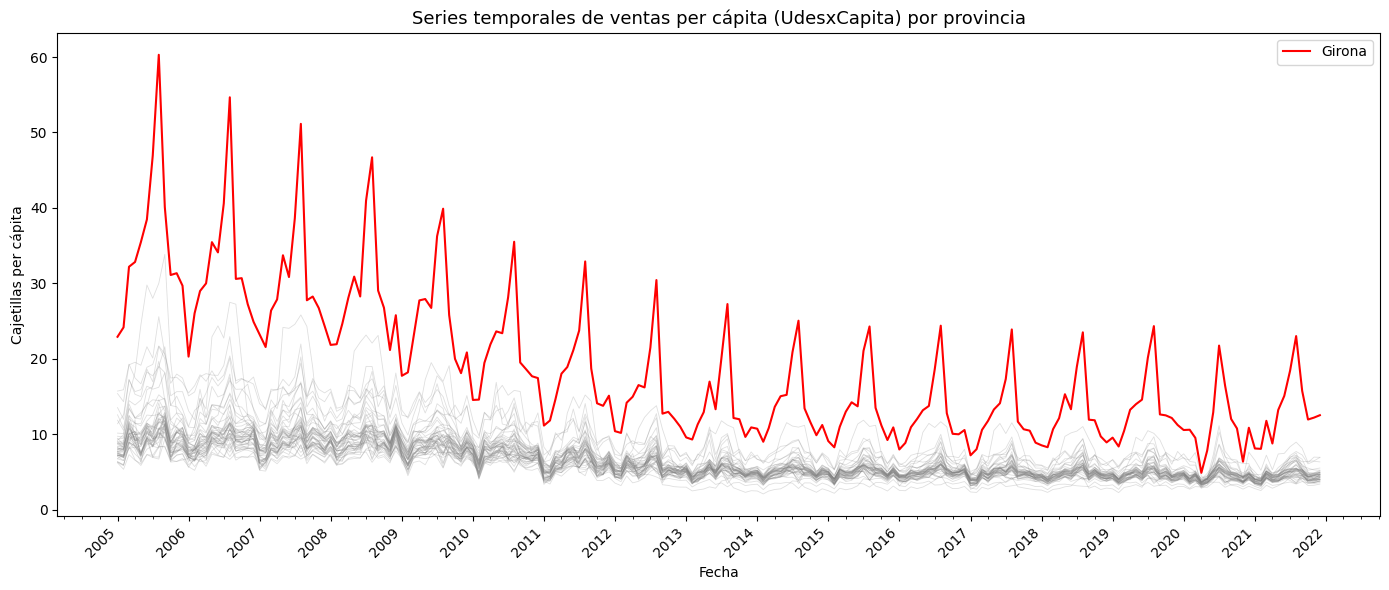

In [5]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Todas las provincias en gris claro como contexto
for prov, grupo in df.groupby('Provincias'):
    if prov != 'Girona':
        ax.plot(grupo['fecha_ts'], grupo['UdesxCapita'],
                alpha=0.25, linewidth=0.6, color='gray')

# Girona destacada en rojo (es el hallazgo principal del gráfico)
girona = df[df['Provincias'] == 'Girona']
ax.plot(girona['fecha_ts'], girona['UdesxCapita'],
        color='red', linewidth=1.5, label='Girona')

# Formato del eje temporal: mostramos año y mes abreviado
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title('Series temporales de ventas per cápita (UdesxCapita) por provincia', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cajetillas per cápita')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

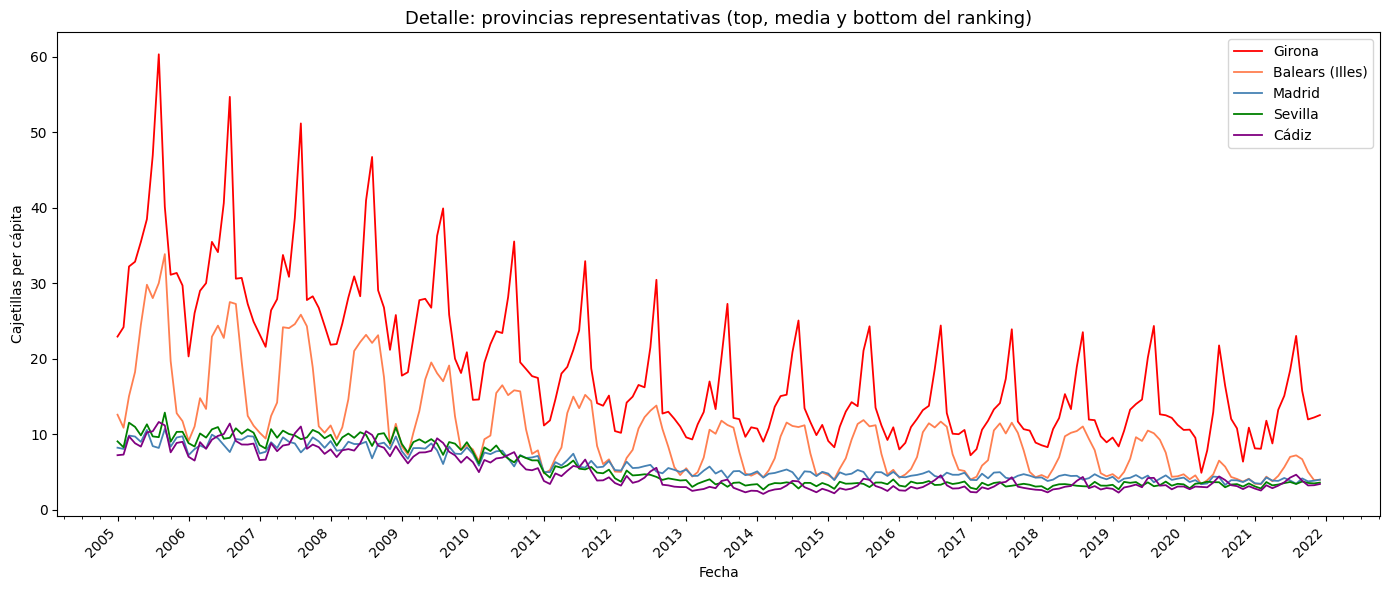

In [6]:
# Segundo gráfico: subconjunto de provincias representativas para ver mejor los patrones
provincias_detalle = ['Girona', 'Balears (Illes)', 'Madrid', 'Sevilla', 'Cádiz']
colores_detalle = ['red', 'coral', 'steelblue', 'green', 'purple']

fig, ax = plt.subplots(figsize=(14, 6))

for prov, color in zip(provincias_detalle, colores_detalle):
    datos = df[df['Provincias'] == prov].sort_values('fecha_ts')
    ax.plot(datos['fecha_ts'], datos['UdesxCapita'],
            color=color, linewidth=1.3, label=prov)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title('Detalle: provincias representativas (top, media y bottom del ranking)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cajetillas per cápita')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Hallazgos principales:**

- **Tendencia decreciente general:** Todas las provincias muestran una caída sostenida en las ventas per cápita entre 2005 y 2021. Esto es coherente con la legislación antitabaco progresiva en España (Ley 28/2005 y Ley 42/2010) y las sucesivas subidas de impuestos especiales.

- **Estacionalidad clara:** Se observan picos recurrentes cada verano (meses 6-8) y valles en invierno, probablemente vinculados al turismo y al consumo estival.

- **Una provincia atípica:** Hay una serie que destaca muy por encima del resto durante todo el periodo. Se trata de Girona, provincia fronteriza con Francia, donde el diferencial de precios del tabaco entre ambos países genera un efecto de compra transfronteriza que infla las ventas per cápita.

- **Efecto COVID-19:** En abril de 2020 se aprecia una caída brusca en todas las series, coincidiendo con el confinamiento estricto, seguida de una recuperación parcial.

---
## Pregunta 2: Ranking de provincias por UdesxCapita

**Realiza una representación gráfica ordenada del ranking de provincias de más a menos venta, usando la media de UdesxCapita como referencia.**

Calculamos la media de `UdesxCapita` por provincia a lo largo de todo el periodo y lo representamos en un gráfico de barras horizontales (con 48 provincias, las barras verticales serían ilegibles).

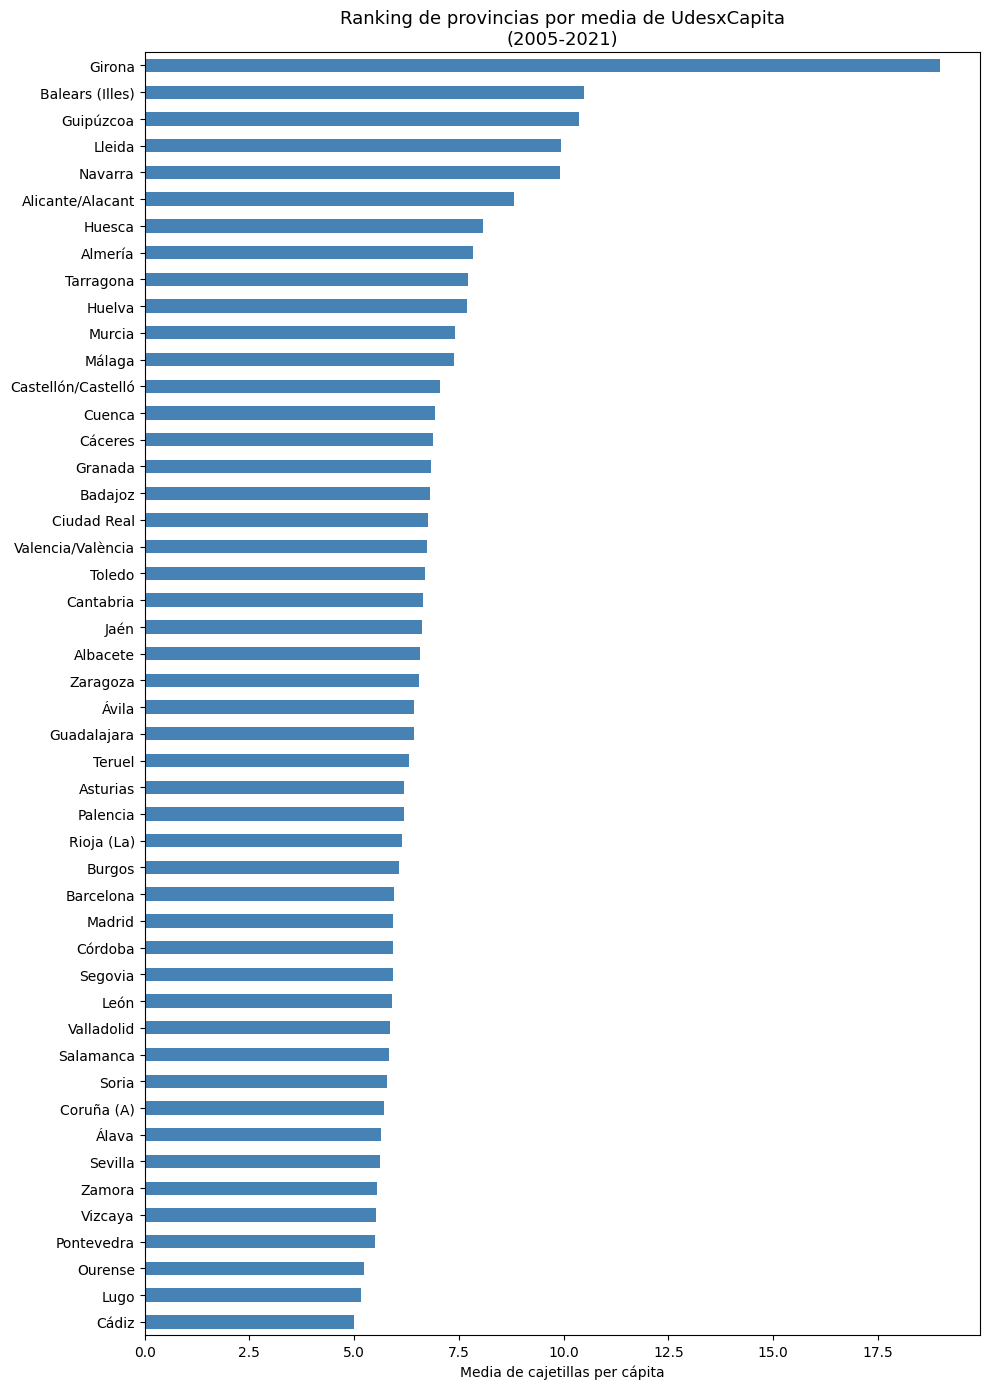

=== TOP 5 (más ventas per cápita) ===
Provincias
Girona             18.98
Balears (Illes)    10.48
Guipúzcoa          10.36
Lleida              9.93
Navarra             9.90

=== BOTTOM 5 (menos ventas per cápita) ===
Provincias
Cádiz         4.99
Lugo          5.17
Ourense       5.24
Pontevedra    5.49
Vizcaya       5.51


In [7]:
# Ranking de provincias por media de UdesxCapita
ranking = df.groupby('Provincias')['UdesxCapita'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
ranking.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Ranking de provincias por media de UdesxCapita\n(2005-2021)', fontsize=13)
ax.set_xlabel('Media de cajetillas per cápita')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Mostramos top 5 y bottom 5
print('=== TOP 5 (más ventas per cápita) ===')
print(ranking.tail(5).sort_values(ascending=False).round(2).to_string())
print('\n=== BOTTOM 5 (menos ventas per cápita) ===')
print(ranking.head(5).round(2).to_string())

**Hallazgos del ranking:**

- **Girona lidera de forma aplastante** con una media de ~19 cajetillas per cápita, casi el doble de la segunda (Baleares, ~10.5). El efecto frontera con Francia es determinante: los compradores franceses cruzan la frontera para adquirir tabaco más barato en España, inflando las cifras de venta respecto a la población local.

- **Las provincias del top son fronterizas y/o turísticas:** Guipúzcoa (frontera con Francia por Irún), Lleida (frontera con Andorra), Navarra, Huesca, Baleares y Alicante. Todas ellas comparten el factor de compra transfronteriza o turismo internacional.

- **En el bottom** encontramos provincias atlánticas y del interior (Cádiz, Lugo, Ourense, Pontevedra, Vizcaya), sin efecto frontera ni gran afluencia turística extranjera.

- Este ranking será fundamental para interpretar los clusters de la Pregunta 4: esperamos que los grupos de provincias estén correlacionados con su posición en este ranking.

---
## Pregunta 3: ¿Existe convergencia absoluta?

**La dirección general quiere llevar a cabo acciones comerciales diferenciadas por zonas. ¿Podemos decir que existe convergencia absoluta? ¿Se pueden llevar a cabo acciones diferenciadas?**

La convergencia absoluta implicaría que todas las provincias tienden a un mismo comportamiento con el tiempo, de modo que la dispersión entre ellas se reduce hasta desaparecer.

Para analizarlo, calculamos la **sigma-convergencia**: la desviación típica (y la varianza) de `UdesxCapita` entre todas las provincias para cada periodo. Si hubiera convergencia absoluta, esta dispersión tendería a cero.

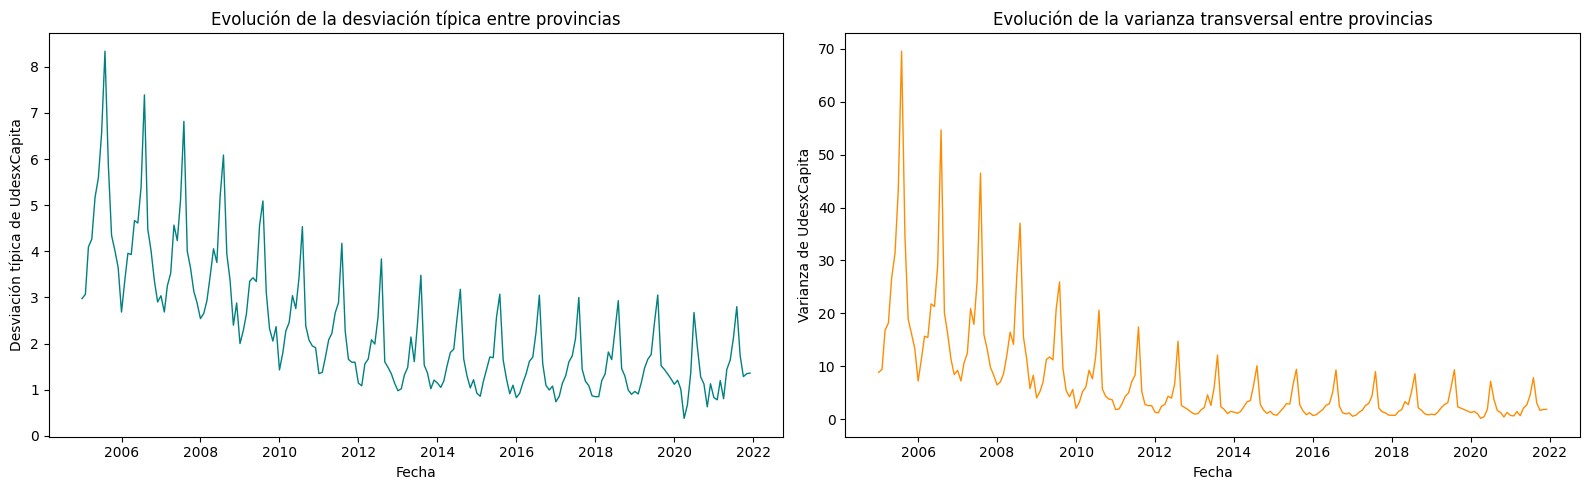

Desviación típica media (primeros 12 meses): 4.83
Desviación típica media (últimos 12 meses):  1.45

Reducción: -70.1%


In [8]:
# Sigma-convergencia: desviación típica transversal por periodo
sigma = df.groupby('fecha_ts')['UdesxCapita'].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Desviación típica
axes[0].plot(sigma.index, sigma.values, color='teal', linewidth=1)
axes[0].set_title('Evolución de la desviación típica entre provincias', fontsize=12)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Desviación típica de UdesxCapita')

# Gráfico 2: Varianza (para ver mejor la magnitud de los picos)
varianza = df.groupby('fecha_ts')['UdesxCapita'].var()
axes[1].plot(varianza.index, varianza.values, color='darkorange', linewidth=1)
axes[1].set_title('Evolución de la varianza transversal entre provincias', fontsize=12)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Varianza de UdesxCapita')

plt.tight_layout()
plt.show()

# Comparamos el inicio y el final del periodo
print(f'Desviación típica media (primeros 12 meses): {sigma.iloc[:12].mean():.2f}')
print(f'Desviación típica media (últimos 12 meses):  {sigma.iloc[-12:].mean():.2f}')
print(f'\nReducción: {((sigma.iloc[-12:].mean() / sigma.iloc[:12].mean()) - 1) * 100:.1f}%')

**Interpretación:**

La dispersión entre provincias se ha reducido significativamente a lo largo del periodo (~70% de reducción en la desviación típica). Esto indica que las provincias se han ido pareciendo más entre sí, lo que en economía se denomina **sigma-convergencia**.

Sin embargo, **no existe convergencia absoluta** por dos motivos:

1. La dispersión no llega a cero: al final del periodo sigue habiendo diferencias notables entre provincias.
2. Los picos estacionales persisten, indicando que hay provincias cuyo comportamiento difiere sistemáticamente del resto (especialmente en verano, cuando el turismo amplifica las diferencias).

**Respuesta a la dirección general:** Las provincias NO se comportan de manera homogénea. Aunque la brecha se ha reducido, siguen existiendo diferencias estructurales. **Sí tiene sentido llevar a cabo acciones comerciales diferenciadas por zonas**. El siguiente paso es identificar cuántos grupos diferenciados existen.

---
## Pregunta 4: Clubes de convergencia (Clustering)

**¿En cuántos grupos (clubes) podemos dividir las provincias según el comportamiento de sus series temporales? ¿Existe algún patrón de comportamiento geográfico y/o relacionado con el ranking de la pregunta 2?**

Para agrupar las provincias, aplicamos **K-Means** sobre las series temporales. Cada provincia se representa como un vector de 204 valores (uno por mes), y normalizamos con `StandardScaler` para que el clustering se base en la *forma* del comportamiento, no solo en el nivel.

Para elegir el número de clusters usamos dos métodos complementarios: el **método del codo** (inercia) y el **método de la silueta**.

In [9]:
# Preparamos los datos: tabla pivote con provincias en filas y meses en columnas
pivot = df.pivot_table(index='Provincias', columns='fecha_ts', values='UdesxCapita')
print(f'Tabla pivote: {pivot.shape[0]} provincias x {pivot.shape[1]} periodos')

# Normalización
scaler = StandardScaler()
X = scaler.fit_transform(pivot.values)

Tabla pivote: 48 provincias x 204 periodos


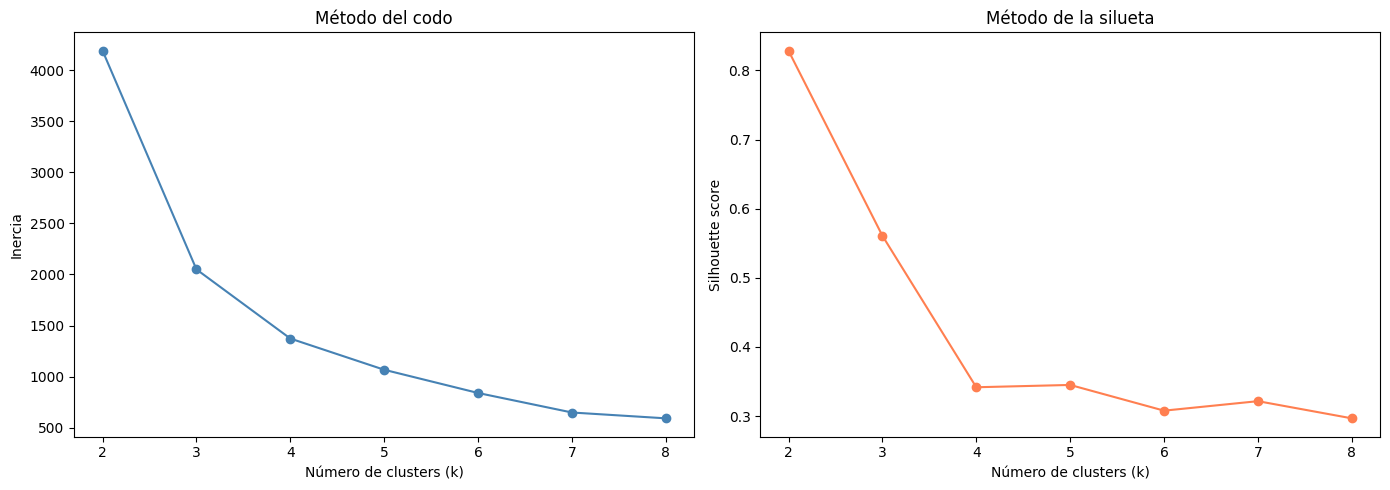

k=2: silueta=0.8286
k=3: silueta=0.5609
k=4: silueta=0.3417
k=5: silueta=0.3451
k=6: silueta=0.3079
k=7: silueta=0.3216
k=8: silueta=0.2967


In [10]:
# Método del codo + Silueta para elegir k
rango_k = range(2, 9)
inercias = []
siluetas = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Codo
axes[0].plot(rango_k, inercias, marker='o', color='steelblue')
axes[0].set_title('Método del codo', fontsize=12)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

# Silueta
axes[1].plot(rango_k, siluetas, marker='o', color='coral')
axes[1].set_title('Método de la silueta', fontsize=12)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

for k, s in zip(rango_k, siluetas):
    print(f'k={k}: silueta={s:.4f}')

Como complemento visual, representamos un **dendrograma** (clustering jerárquico con método Ward) que permite ver cómo se agrupan las provincias de forma natural y a qué distancia se fusionan los clusters.

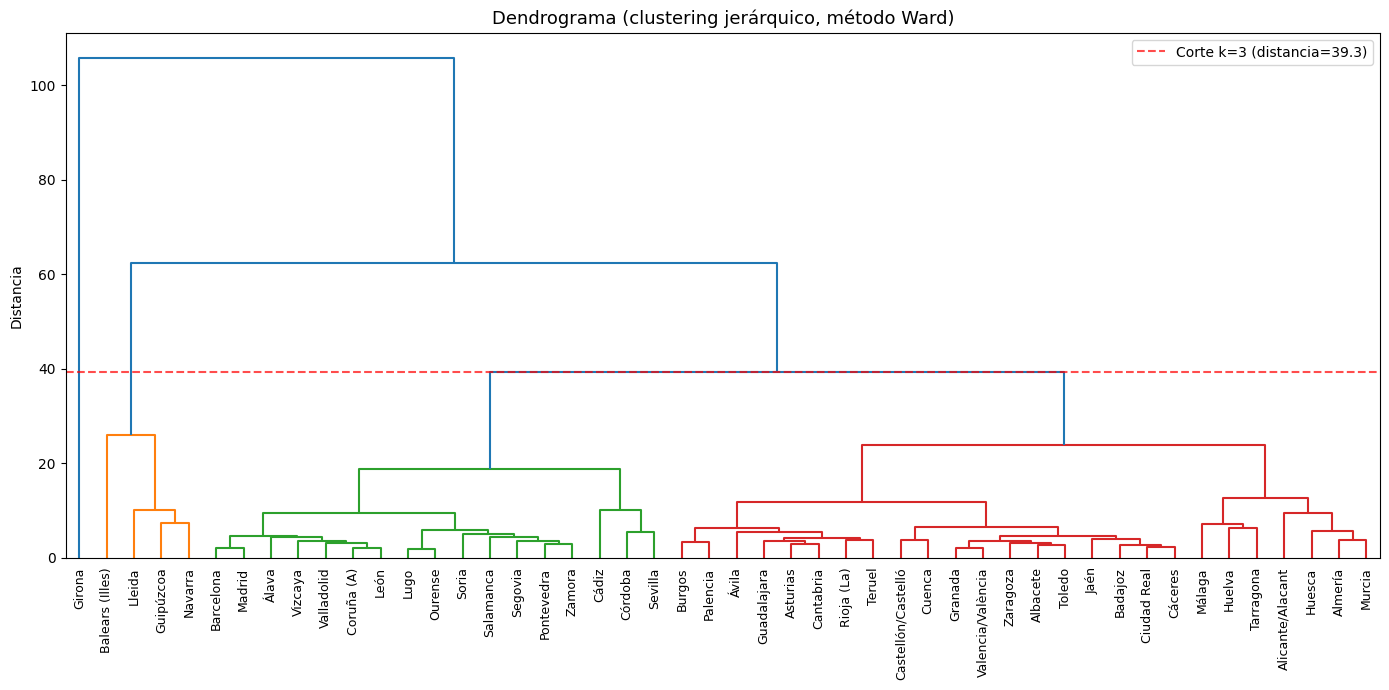

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Clustering jerárquico con método Ward
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, labels=pivot.index.tolist(), leaf_rotation=90, leaf_font_size=9, ax=ax,
           color_threshold=Z[-3, 2])  # Coloreamos según corte en k=3

ax.set_title('Dendrograma (clustering jerárquico, método Ward)', fontsize=13)
ax.set_ylabel('Distancia')
ax.axhline(y=Z[-3, 2], color='red', linestyle='--', alpha=0.7,
           label=f'Corte k=3 (distancia={Z[-3, 2]:.1f})')
ax.legend()
plt.tight_layout()
plt.show()

**Elección de k:**

- La **silueta máxima** se da en k=2 (0.83), pero ese resultado es trivial: separa únicamente a Girona (el outlier extremo) del resto de provincias. No aporta información útil.
- El **método del codo** muestra un quiebre claro en k=3: la caída de inercia de k=2 a k=3 es muy pronunciada, y a partir de k=3 la curva se aplana. Ese es el codo.
- Con **k=3** (silueta=0.56) obtenemos una estructura interpretable y con sentido de negocio: Girona como outlier, un grupo de provincias fronterizas/turísticas, y el grueso de provincias con comportamiento estándar.

Se ha explorado también **k=4**: lo que ocurre es que el club grande (40 provincias) se divide en dos subgrupos, pero la silueta cae a 0.34 y los dos subgrupos resultantes no presentan un patrón geográfico o comercial diferenciado que justifique la complejidad adicional.

Optamos por **k=3**, que ofrece el mejor equilibrio entre parsimonia e interpretabilidad para la dirección general.


In [12]:
# Aplicamos K-Means con k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
pivot['club'] = km.fit_predict(X)

# Mostramos las provincias de cada club
for c in sorted(pivot['club'].unique()):
    provs = sorted(pivot[pivot['club'] == c].index.tolist())
    media_global = df[df['Provincias'].isin(provs)]['UdesxCapita'].mean()
    print(f'\nClub {c} ({len(provs)} provincias, media UdesxCapita={media_global:.2f}):')
    print(f'  {", ".join(provs)}')


Club 0 (7 provincias, media UdesxCapita=9.34):
  Alicante/Alacant, Almería, Balears (Illes), Guipúzcoa, Huesca, Lleida, Navarra

Club 1 (1 provincias, media UdesxCapita=18.98):
  Girona

Club 2 (40 provincias, media UdesxCapita=6.28):
  Albacete, Asturias, Badajoz, Barcelona, Burgos, Cantabria, Castellón/Castelló, Ciudad Real, Coruña (A), Cuenca, Cáceres, Cádiz, Córdoba, Granada, Guadalajara, Huelva, Jaén, León, Lugo, Madrid, Murcia, Málaga, Ourense, Palencia, Pontevedra, Rioja (La), Salamanca, Segovia, Sevilla, Soria, Tarragona, Teruel, Toledo, Valencia/València, Valladolid, Vizcaya, Zamora, Zaragoza, Álava, Ávila


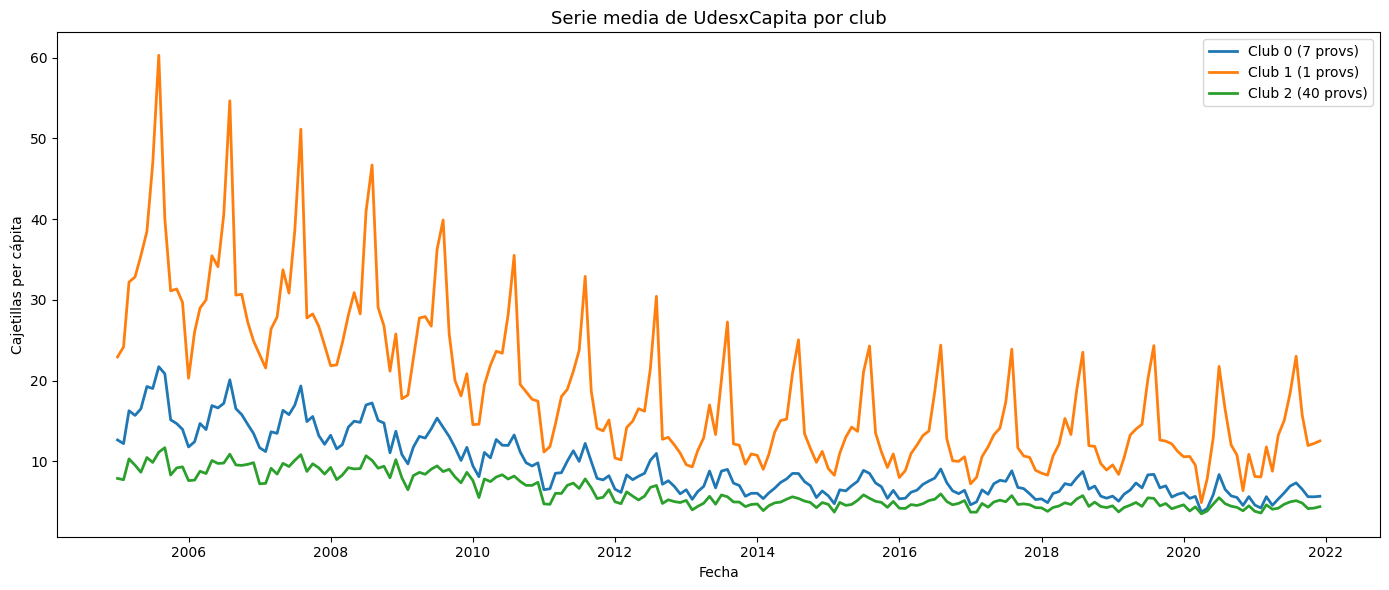

In [13]:
# Series medias por club
# Para este gráfico, excluimos la columna 'club' de las columnas temporales
cols_temporales = [c for c in pivot.columns if c != 'club']
medias_club = pivot.groupby('club')[cols_temporales].mean().T

fig, ax = plt.subplots(figsize=(14, 6))
for col in medias_club.columns:
    n_provs = (pivot['club'] == col).sum()
    ax.plot(medias_club.index, medias_club[col], linewidth=2,
            label=f'Club {col} ({n_provs} provs)')

ax.set_title('Serie media de UdesxCapita por club', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cajetillas per cápita')
ax.legend()
plt.tight_layout()
plt.show()

**Cruce con el ranking (Pregunta 2):**

Veamos cómo se distribuyen los clubs en el ranking de ventas per cápita.

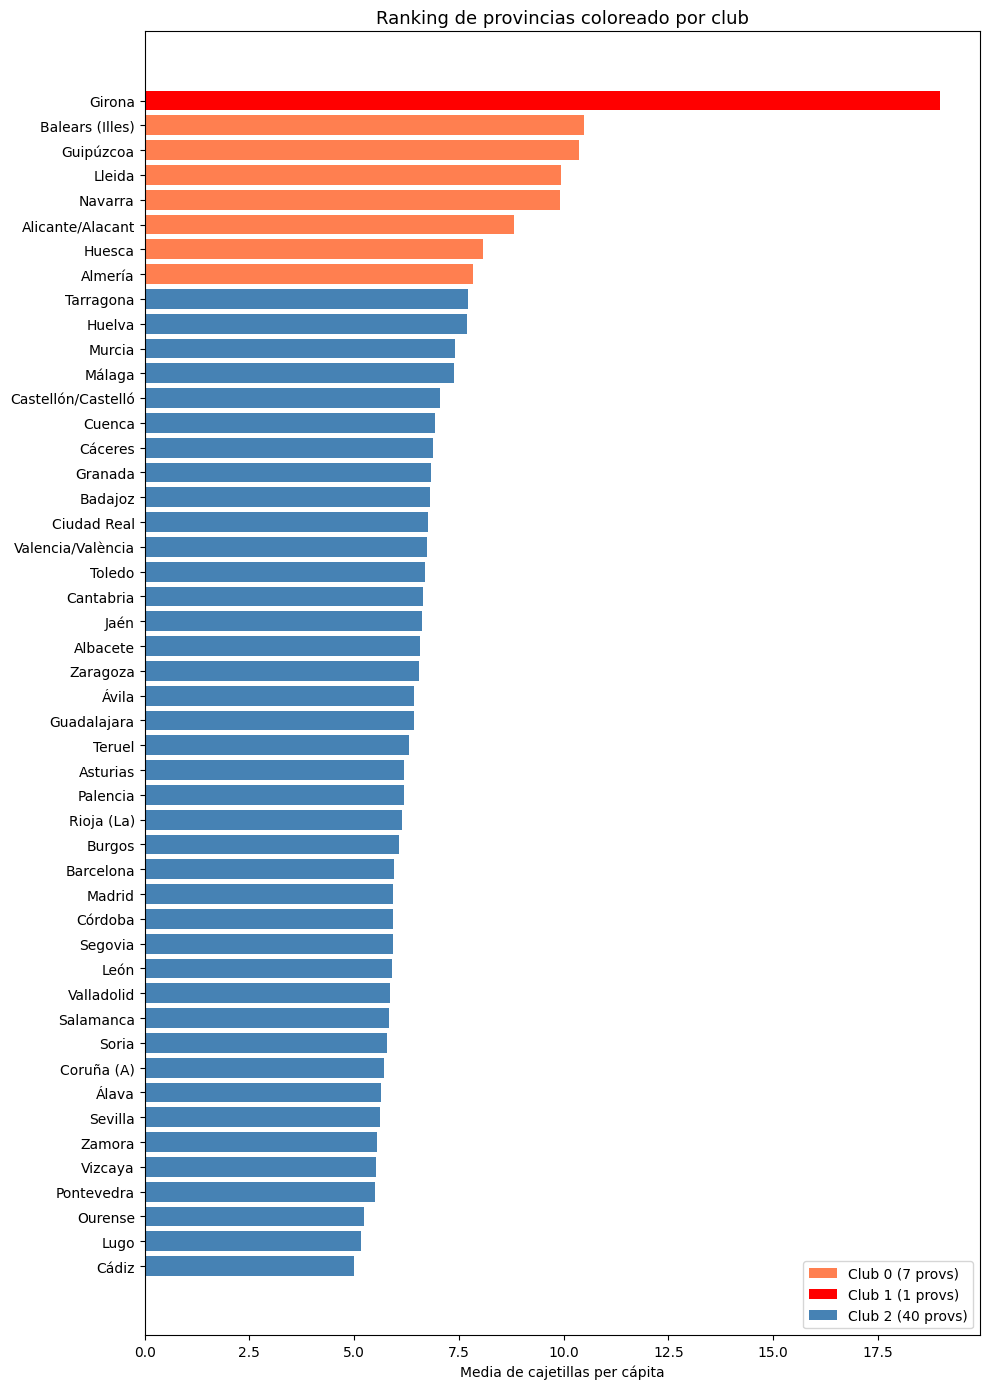

In [14]:
# Añadimos el club al ranking
ranking_df = ranking.reset_index()
ranking_df.columns = ['Provincias', 'media_udes']
ranking_df = ranking_df.merge(pivot[['club']].reset_index(), on='Provincias')
ranking_df = ranking_df.sort_values('media_udes', ascending=True)

# Colores por club
colores_club = {0: 'coral', 1: 'red', 2: 'steelblue'}
colores = ranking_df['club'].map(colores_club)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(ranking_df['Provincias'], ranking_df['media_udes'], color=colores)
ax.set_title('Ranking de provincias coloreado por club', fontsize=13)
ax.set_xlabel('Media de cajetillas per cápita')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores_club[c], label=f'Club {c} ({(pivot["club"]==c).sum()} provs)')
                   for c in sorted(colores_club.keys())]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Interpretación de los clubes:**

Los tres clubs tienen una lógica geográfica y comercial clara:

- **Club 1 (1 provincia — Girona):** Outlier extremo. La provincia fronteriza con Francia por excelencia, con ventas per cápita que duplican o triplican al resto. El diferencial de precios del tabaco España-Francia genera un flujo masivo de compra transfronteriza. Este club justifica por sí solo una estrategia comercial específica.

- **Club 0 (~7 provincias fronterizas y turísticas):** Incluye Baleares, Guipúzcoa, Lleida (frontera con Andorra), Navarra, Huesca, Alicante y Almería. Son provincias con ventas per cápita elevadas por efecto turismo internacional y/o cercanía a fronteras. Ocupan las posiciones altas del ranking.

- **Club 2 (~40 provincias):** El grueso del mercado. Provincias con comportamiento estándar, sin efectos fronterizos ni turísticos atípicos. Ocupan la parte media y baja del ranking.

**Patrón geográfico:** Existe un patrón claro. Las provincias del arco mediterráneo, las fronterizas con Francia/Andorra y las islas se agrupan en los clubes de alto consumo. Las provincias atlánticas y del interior castellano se agrupan en el club estándar. Esto confirma que **el factor geográfico (frontera + turismo) es el principal diferenciador** del consumo aparente de tabaco.

---
## Pregunta 5: Predicción a 12 meses

**Realizad una predicción a 12 meses para, como mínimo, una provincia de cada club. ¿Hay clubes cuyas series temporales sean más fácilmente predecibles que otros?**

Seleccionamos una provincia representativa de cada club y aplicamos **Holt-Winters (ExponentialSmoothing)** con componentes aditivos de tendencia y estacionalidad (periodo=12 meses).

Provincias seleccionadas:
- **Club 2 (estándar):** Madrid — provincia grande, comportamiento representativo del grueso del mercado.
- **Club 0 (fronterizo-turístico):** Baleares — fuerte estacionalidad turística.
- **Club 1 (outlier):** Girona — el caso extremo.

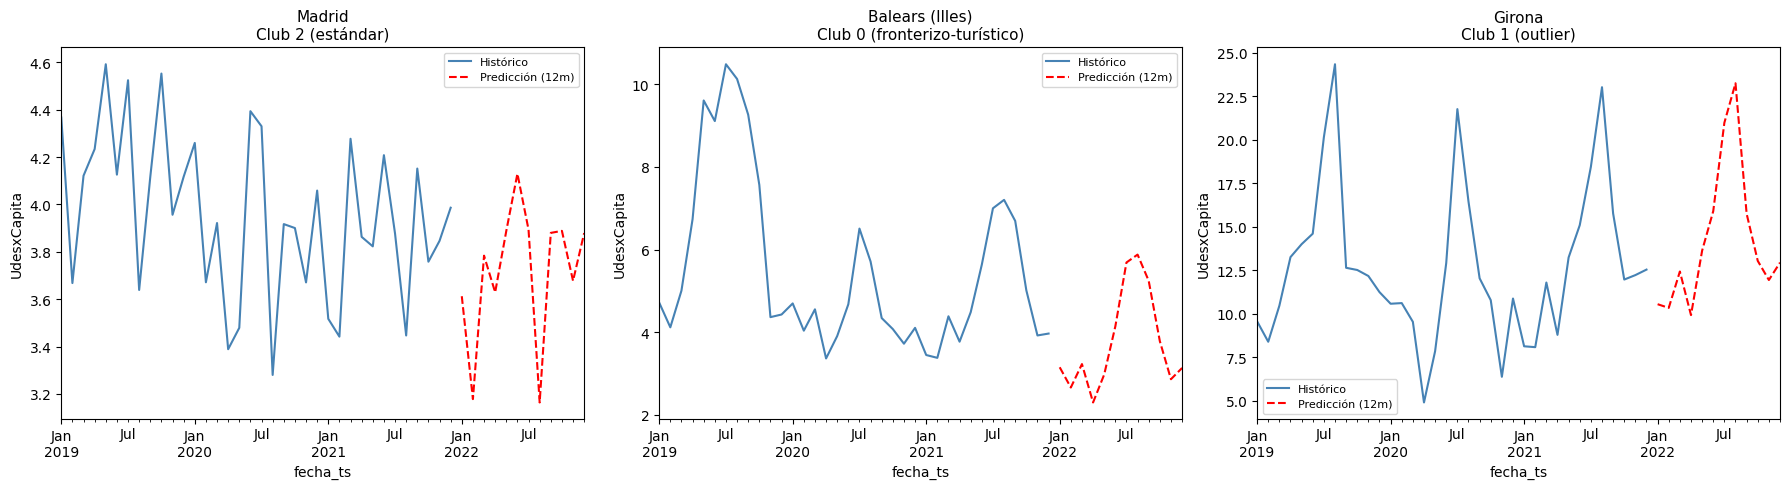

In [15]:
# Provincias a predecir (una por club)
provincias_pred = {
    'Club 2 (estándar)': 'Madrid',
    'Club 0 (fronterizo-turístico)': 'Balears (Illes)',
    'Club 1 (outlier)': 'Girona'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
resultados = {}

for ax, (club_label, prov) in zip(axes, provincias_pred.items()):
    # Preparamos la serie temporal
    serie = df[df['Provincias'] == prov].set_index('fecha_ts')['UdesxCapita'].sort_index()
    serie.index.freq = 'MS'

    # Ajustamos Holt-Winters aditivo
    modelo = ExponentialSmoothing(
        serie,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    resultado = modelo.fit(optimized=True)
    prediccion = resultado.forecast(12)

    # Guardamos métricas
    residuos = resultado.resid.dropna()
    mae = np.abs(residuos).mean()
    resultados[prov] = {'club': club_label, 'AIC': resultado.aic, 'MAE': mae}

    # Gráfico: últimos 36 meses históricos + 12 de predicción
    serie.tail(36).plot(ax=ax, label='Histórico', color='steelblue')
    prediccion.plot(ax=ax, label='Predicción (12m)', color='red', linestyle='--')
    ax.set_title(f'{prov}\n{club_label}', fontsize=11)
    ax.set_ylabel('UdesxCapita')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Tabla comparativa de métricas
df_resultados = pd.DataFrame(resultados).T
df_resultados['MAE'] = df_resultados['MAE'].astype(float).round(3)
df_resultados['AIC'] = df_resultados['AIC'].astype(float).round(1)
print('=== Comparativa de predicciones por club ===')
print(df_resultados.to_string())

=== Comparativa de predicciones por club ===
                                          club    AIC    MAE
Madrid                       Club 2 (estándar) -281.9  0.352
Balears (Illes)  Club 0 (fronterizo-turístico)  138.6  0.966
Girona                        Club 1 (outlier)  309.2  1.446


**Sobre las métricas utilizadas:**

- **MAE (Mean Absolute Error):** es el error absoluto medio de los residuos del modelo sobre los datos históricos. Cuanto menor, mejor ajuste. Tiene la ventaja de estar en las mismas unidades que la variable (cajetillas per cápita), lo que facilita su interpretación.
- **AIC (Akaike Information Criterion):** mide la calidad relativa del modelo penalizando su complejidad. Un AIC más bajo indica mejor equilibrio entre ajuste y parsimonia. Los valores negativos (como el de Madrid) no son un error: simplemente indican un ajuste muy bueno con pocos parámetros.

**Comparación entre clubes:**

- **Madrid (Club estándar, MAE=0.35, AIC=-281.9)** es la serie más predecible. Presenta una tendencia decreciente suave, estacionalidad moderada y estable, y poca volatilidad. El modelo ajusta bien y la predicción continúa la tendencia de forma coherente. Su MAE es bajo en relación a su nivel de ventas (~6 cajetillas per cápita), y su AIC es el más bajo de los tres.

- **Baleares (Club fronterizo-turístico, MAE=0.97, AIC=138.6)** tiene una estacionalidad mucho más pronunciada (picos de verano enormes por el turismo) que introduce mayor dificultad. El modelo captura el patrón general, pero los picos estivales son más difíciles de replicar con precisión. Tanto el MAE como el AIC empeoran notablemente respecto a Madrid.

- **Girona (Club outlier, MAE=1.45, AIC=309.2)** es la más difícil de predecir. La estacionalidad es extrema y está distorsionada por el efecto frontera, que añade un componente externo (políticas de precios francesas, controles fronterizos) que un modelo univariante no puede capturar. Presenta el MAE y AIC más altos.

**Conclusión para la dirección general:** Las series de las provincias estándar son más predecibles y permiten una planificación de inventarios y logística más fiable. Las provincias fronterizas y turísticas requieren modelos más sofisticados (o variables explicativas adicionales como precios del tabaco en Francia o llegadas de turistas) para mejorar la precisión de las predicciones.


---
## Resumen ejecutivo

El análisis de las ventas de cigarrillos per cápita en las 48 provincias españolas (2005-2021) revela que:

1. **No existe convergencia absoluta:** aunque la dispersión entre provincias se ha reducido (~70%), siguen existiendo diferencias estructurales significativas. La dirección general puede y debe diseñar acciones comerciales diferenciadas.

2. **Existen 3 clubes diferenciados:**
   - Un **club estándar** (40 provincias) con comportamiento homogéneo y ventas per cápita moderadas.
   - Un **club fronterizo-turístico** (7 provincias) con ventas elevadas por factores geográficos.
   - Un **outlier** (Girona) que requiere tratamiento individualizado.

3. **La predecibilidad varía por club:** las provincias estándar son fácilmente predecibles con modelos básicos, mientras que las fronterizas y turísticas requieren enfoques más sofisticados que incorporen variables externas.

4. **Nota:** la variable `UdesxCapita` del dataset se calcula como Unidades / Población (no Euros / Población como indica el enunciado).